# Part 1, MZI design

We start by importing all the libraries, we will use

In [1]:
import numpy as np
import gdsfactory as gf

gf.gpdk.PDK.activate()

#### Then Start defining the MZI function.

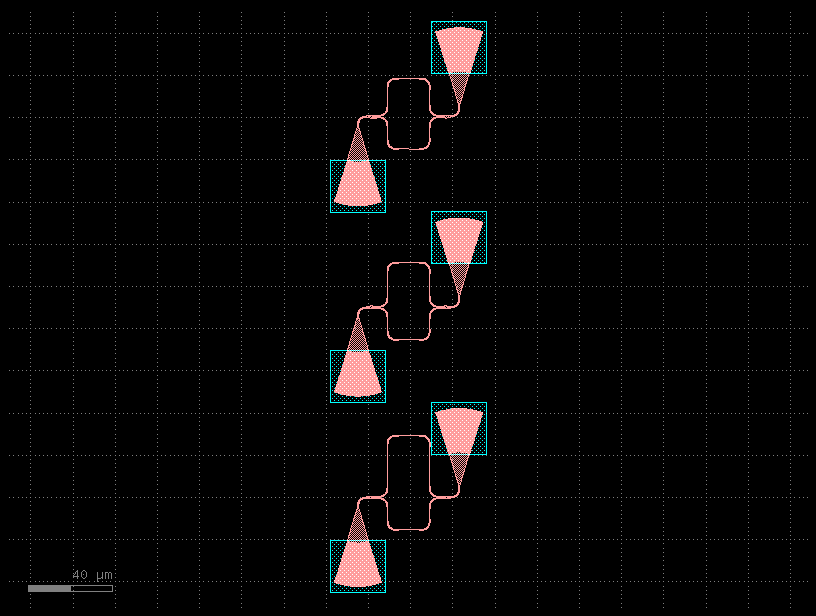

In [11]:
def MZI_generator(wavelength = 1.55,
                  core_material= 0,
                  cladd_material= 0,
                  neff= 0,
                  ng = 4.296053, # Group index of Silicon and
                  FSR = 20,
                  wg_width = 0.420,
                  thick = 0.22,
                  wg_default_width = 0.5,
                  taper_length = 5.0,
                  bend_radius = 10,
                  splitter_length = 2.0,
                  strip_length = 5.0,
                  mzi_pos = (0,0),
                  layer = (1,0),):


    ## Cálculo del delta de L

    total_x_length = 26.15 + 6*bend_radius + 2*splitter_length +  2*taper_length + 2*strip_length ## um
    total_y_length = 2*40.1 + 2*bend_radius  ## um

    delL = 1000 * (wavelength)**2 / (FSR*ng)  ##um

    # //////  INICIO DE LA FUNCION MZI
    # We define an sketch where we will place the components
    c = gf.Component()

    poly = gf.Component()

    # ////////////////////////////////////////////////////

    # What follows is a bend to place the MZI horizontal


    # Base bend (by default: left → up, or depends on PDK)
    bend = gf.components.bend_euler(width=wg_default_width,radius=bend_radius, angle=-90)
    ref_bend = c.add_ref(bend)

    # ////////////////////////////////////////////////////

    # what follows is to place the splitter, this would be out center of the MZI (origin)

    # Default widths from paper (µm)
    widths = [
        0.5, 0.5, 0.6, 0.7, 0.9,
        1.26, 1.4, 1.4, 1.4, 1.4,
        1.31, 1.2, 1.2
    ]

    n = len(widths)
    dx = splitter_length / n

    # x positions
    xs = np.linspace(0, splitter_length, n)

    # Upper and lower boundaries
    y_top = np.array(widths) / 2
    y_bot = -y_top

    # Build central polygon
    points = []

    # top boundary (left → right)
    for x, y in zip(xs, y_top):
        points.append((x, y))

    # bottom boundary (right → left)
    for x, y in zip(xs[::-1], y_bot[::-1]):
        points.append((x, y))

    poly.add_polygon(points, layer=layer)

    poly_ref = c.add_ref(poly)

    poly_ref.move((mzi_pos[0], mzi_pos[1]))

    # --- Split into two arms at the end ---
    split_gap = widths[-1] - wg_default_width

    # Upper arm
    upper_taper = gf.components.taper(
        length=taper_length,
        width1=wg_default_width,
        width2=wg_width,
        layer=layer,
    )
    t1 = c.add_ref(upper_taper)
    t1.move((mzi_pos[0]+splitter_length,mzi_pos[1] + split_gap / 2))

    # Lower arm
    lower_taper = gf.components.taper(
        length=taper_length,
        width1=wg_default_width,
        width2=wg_width,
        layer=layer,
    )
    t2 = c.add_ref(lower_taper)
    t2.move((mzi_pos[0]+splitter_length,mzi_pos[1] -split_gap / 2))

    c.add_port(
        name="poly_in",
        center=(mzi_pos[0], mzi_pos[1]),
        width=wg_default_width,
        orientation=180,
        layer=layer,
    )

    ## At the end we connect:

    ref_bend.connect("o2",c.ports["poly_in"])


    # ////////////////////////////////////////////////////

    # What follows is to set the in and out grating couplers

    # We define the input and output gratings for now, the input need to be rotated and port-renamed
    gr_coupler_output = gf.components.grating_coupler_elliptical(polarization='te',
                                                 taper_length=16.6,
                                                 taper_angle=40,
                                                 wavelength=wavelength,
                                                 fiber_angle=15,
                                                 grating_line_width=0.343,
                                                 neff=2.638, nclad=1.443,
                                                 n_periods=30,
                                                 big_last_tooth=False,
                                                 layer_slab='SLAB150',
                                                 slab_xmin=-1,
                                                 slab_offset=2,
                                                 spiked=True,
                                                 cross_section='strip').copy()


    #creation of components
    gr_coupler_output = gr_coupler_output.rotate(-90)
    gr_coupler_input = gr_coupler_output.copy()

    #Referencing
    ref_gr_coupler_input = c.add_ref(gr_coupler_input)


    ref_gr_coupler_input.connect("o1",ref_bend.ports["o1"])

    c.add_port(name="Input", port=ref_gr_coupler_input.ports["o2"])



    # ////////////////////////////////////////////////////

    # What follows is to design the two arms


    # --------------------------------------------------
    # 2. First bend (turn upwards)
    # --------------------------------------------------
    bend1 = gf.components.bend_euler(radius=bend_radius, width=wg_width)
    b1_ref = c.add_ref(bend1)
    b1_ref.connect("o1", t1.ports["o2"])

    # Mirrored bend
    b1_mirror = c.add_ref(bend1)
    b1_mirror.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(1+mzi_pos[0], mzi_pos[1]))
    b1_mirror.connect("o1", t2.ports["o2"])

    # Vertical Straight
    str_wg1 =  gf.components.straight(length=strip_length+delL/2, width=wg_width)
    str_wg1_ref = c.add_ref(str_wg1)
    str_wg1_ref.connect("o1", b1_ref.ports["o2"])

    # Mirrored straight
    str_wg1_mirror= gf.components.straight(length=strip_length, width=wg_width)
    str_wg1_ref_mirror = c.add_ref(str_wg1_mirror)
    str_wg1_ref_mirror.connect("o1", b1_mirror.ports["o2"])


    # --------------------------------------------------
    # 3. Second bend (turn right again)
    # --------------------------------------------------
    bend2 = gf.components.bend_euler(radius=bend_radius, width=wg_width,angle=-90)
    b2_ref = c.add_ref(bend2)
    b2_ref.connect("o1", str_wg1_ref.ports["o2"])

    # Mirrored version
    b2_mirror = c.add_ref(bend2)
    b2_mirror.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(1+mzi_pos[0], mzi_pos[1]))
    b2_mirror.connect("o1", str_wg1_ref_mirror.ports["o2"])

    # --------------------------------------------------
    # 4. Long straight waveguide
    # --------------------------------------------------
    str_wg2 = gf.components.straight(length=strip_length, width=wg_width)
    str_wg2_ref = c.add_ref(str_wg2)

    # Connect to second bend
    str_wg2_ref.connect("o1", b2_ref.ports["o2"])

    # Mirrored version
    str_wg2_ref_mirror = c.add_ref(str_wg2)
    str_wg2_ref_mirror.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(mzi_pos[0], mzi_pos[1]+1))
    str_wg2_ref_mirror.connect("o1", b2_mirror.ports["o2"])

    #### HASTA ACA TO_DO EL INTERFEROMETRO DEBE DE DUPLICARSE, lo haremos de forma sistematica, teniendo en cuenta la linea vertical que esta pegada a las salidas

    """

    ## Como elementos a hacerles el espejo son en orden desde los ultimos componentes colocados hacia atras:

    Strip up/down ---> bend up/down ---> strip up/down ----> bend up/down ----> Taper up/down ---> Splitter ---> bend ---> G Coupler


    Primero se comenzara definiendo el plano de espejo para que sea la base de todos los elementos a copiar, ir copiando e ir conectando cada que se va generando


    Estructura basica de generacion de componente:

    ---Referenciar componente ()  [Ya existe el componente, solo hay que copiarlo]

    ---Aplicar mirror ()

    ---Conectar ()

    """


    ########## Strip up/down ###################

    str_wg3_ref = c.add_ref(str_wg2)
    str_wg3_ref.connect("o1", str_wg2_ref.ports["o2"])

    str_wg3_ref_mirror = c.add_ref(str_wg2)
    str_wg3_ref_mirror.connect("o1", str_wg2_ref_mirror.ports["o2"])

    ###########################################

    ########## Bend1 up/down ###################

    bend3_ref = c.add_ref(bend2)
    bend3_ref.connect("o1", str_wg3_ref.ports["o2"])

    bend3_ref_mirror = c.add_ref(bend2)
    bend3_ref_mirror.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(1+mzi_pos[0], mzi_pos[1]))
    bend3_ref_mirror.connect("o1", str_wg3_ref_mirror.ports["o2"])


    ###########################################

    ########## Strip up/down ###################

    str_wg4_ref = c.add_ref(str_wg1)
    str_wg4_ref.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(1+mzi_pos[0], mzi_pos[1]))
    str_wg4_ref.connect("o1", bend3_ref.ports["o2"])

    str_wg4_ref_mirror = c.add_ref(str_wg1_mirror)
    str_wg4_ref_mirror.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(1+mzi_pos[0], mzi_pos[1]))
    str_wg4_ref_mirror.connect("o1", bend3_ref_mirror.ports["o2"])


    ###########################################


    ########## Bends up/down ###################

    bend4_ref = c.add_ref(bend1)
    bend4_ref.connect("o1", str_wg4_ref.ports["o2"])

    bend4_ref_mirror = c.add_ref(bend1)
    bend4_ref_mirror.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(1+mzi_pos[0], mzi_pos[1]))
    bend4_ref_mirror.connect("o1", str_wg4_ref_mirror.ports["o2"])


    ###########################################


    ########## Tapers up/down ###################

    upper_taper1_ref = c.add_ref(upper_taper)
    upper_taper1_ref.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(mzi_pos[0], 1+mzi_pos[1]))
    upper_taper1_ref.connect("o2", bend4_ref.ports["o2"])

    lower_taper1_ref = c.add_ref(lower_taper)
    lower_taper1_ref.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(1+mzi_pos[0], mzi_pos[1]))
    lower_taper1_ref.mirror(p1=(mzi_pos[0], mzi_pos[1]), p2=(mzi_pos[0], 1+mzi_pos[1]))
    lower_taper1_ref.connect("o2", bend4_ref_mirror.ports["o2"])

    ###########################################

    ########## Splitter #####################

    poly2_ref = c.add_ref(poly)
    poly2_ref.mirror(p1=(0, 0), p2=(0, 1))

    c.add_port(
        name="poly1_in",
        center=(2*splitter_length+2*taper_length+4*bend_radius+2*strip_length + mzi_pos[0] , mzi_pos[1]),
        width=wg_default_width,
        orientation=0,
        layer=layer,
    )

    poly2_ref.move((2*splitter_length+2*taper_length+4*bend_radius+2*strip_length + mzi_pos[0] , mzi_pos[1]))

    ###########################################

    ############## Splitter ###################

    ref_bend_out = c.add_ref(bend)
    ref_bend_out.mirror(p1=(mzi_pos[0],mzi_pos[1]),p2=(mzi_pos[0]+1,mzi_pos[1]))
    ref_bend_out.connect("o1", c.ports["poly1_in"])

    ###########################################


    ############## G Coupler ###################

    gr_coupler_output_ref = c.add_ref(gr_coupler_output)
    gr_coupler_output_ref.rotate(180)
    gr_coupler_output_ref.connect("o1", ref_bend_out.ports["o2"])

    ###########################################


    return c, total_x_length,total_y_length

mzi_scketch = gf.Component("MZI_FSR1")

y_pos = 0

for fsr in [20,50,100]:
    mzi = MZI_generator(taper_length=2.0, bend_radius= 5.0 ,FSR=fsr ,mzi_pos=(0,y_pos))

    mzi_scketch.add_ref(mzi[0])
    y_pos += mzi[2]


mzi_scketch.draw_ports()
mzi_scketch.plot()
mzi_scketch.show()